In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
internal = pd.read_csv('../annotations/internal.csv')
external = pd.read_csv("../annotations/external.csv")

annotations = {
    "Intern": {
        "all": internal,
        "by_model": {}
    },
    "Ekstern": {
        "all": external,
        "by_model": {}
    }
}

# Column variable to use later
column = "model"
# Get unique values in "model" column
models = internal[column].unique()

# Variable to use later
other = 'Other car'

# Remove 'Other car' from list
models = models[models != other]

# Fill "by_model" in both internal and external
for annotation in annotations.values():
    df = annotation["all"]
    for model in models:
        annotation["by_model"][f"Model {model}"] = df[df[column] == model]


sns.set_theme(style="darkgrid", font_scale=0.9)

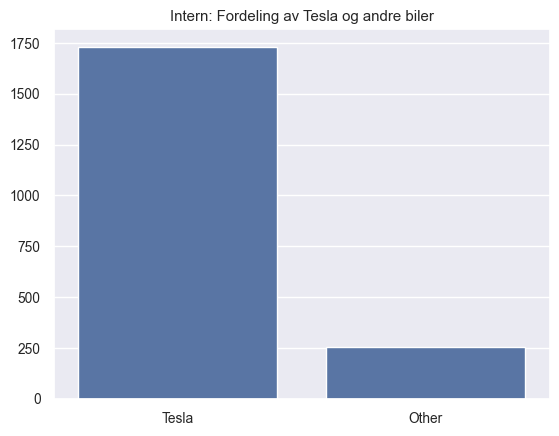

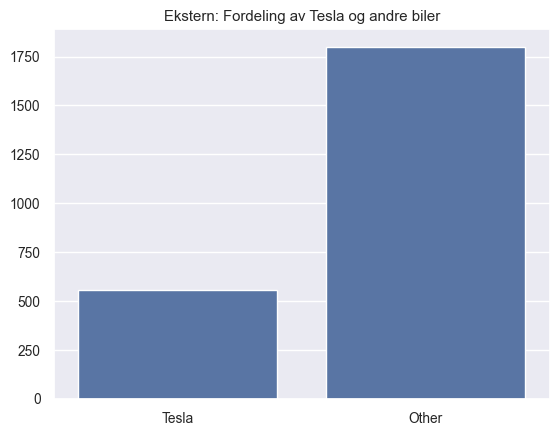

In [12]:
for annotation_name, annotation in annotations.items():
    df = annotation["all"]
    data={'Tesla': len(df[df['model'] != other]), 'Other': len(df[df['model'] == other])}
    plot = sns.barplot(data=data)
    plot.set_title(f'{annotation_name}: Fordeling av Tesla og andre biler')
    plt.show()

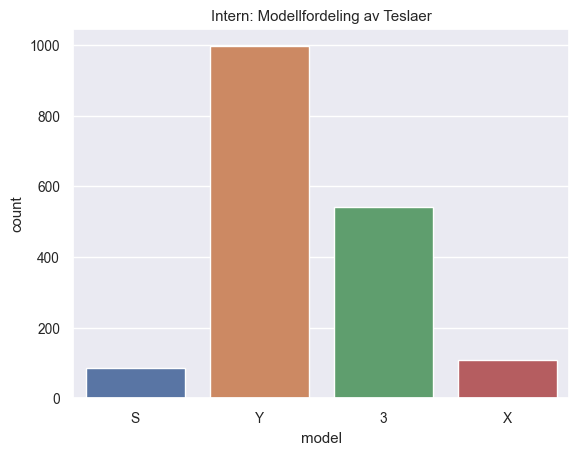

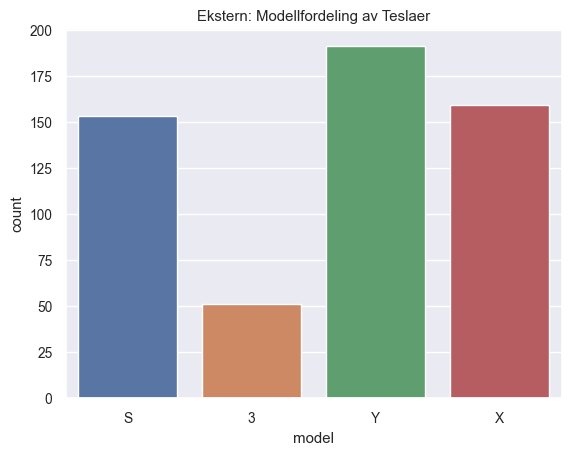

In [13]:
for annotation_name, annotation in annotations.items():
    df = annotation["all"]
    data = df[df['model'] != other]
    plot = sns.countplot(data=data, x='model', hue='model')
    plot.set_title(f'{annotation_name}: Modellfordeling av Teslaer')
    plt.show()

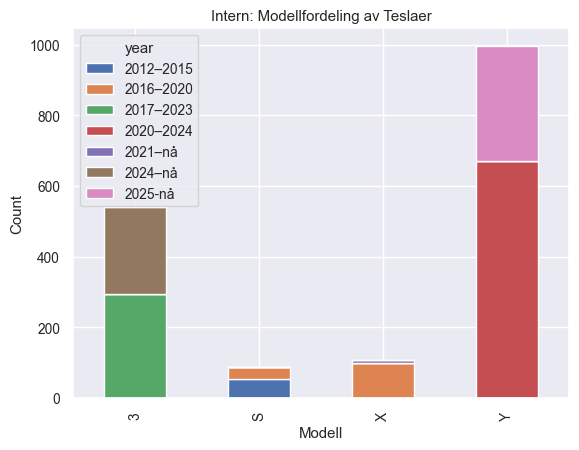

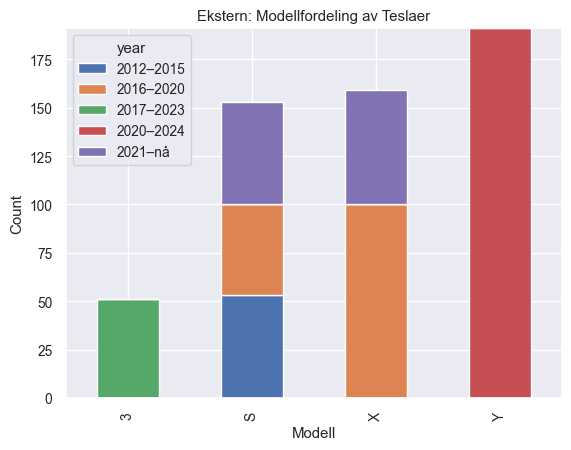

In [14]:
for annotation_name, annotation in annotations.items():
    df = annotation["all"]
    data = df[df['model'] != 'other']
    crosstab = pd.crosstab(data['model'], data['year'])
    crosstab.plot(kind='bar', stacked=True)

    plt.title(f'{annotation_name}: Modellfordeling av Teslaer')
    plt.xlabel('Modell')
    plt.ylabel('Count')
    plt.show()

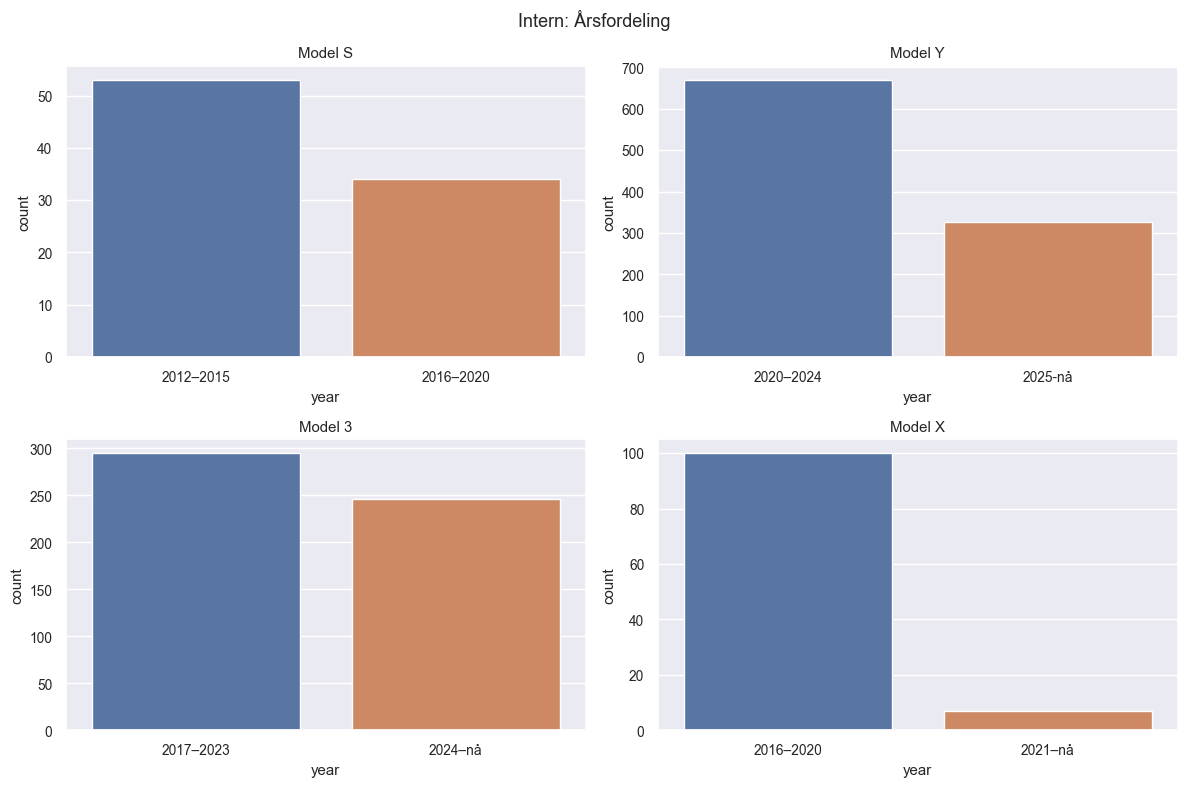

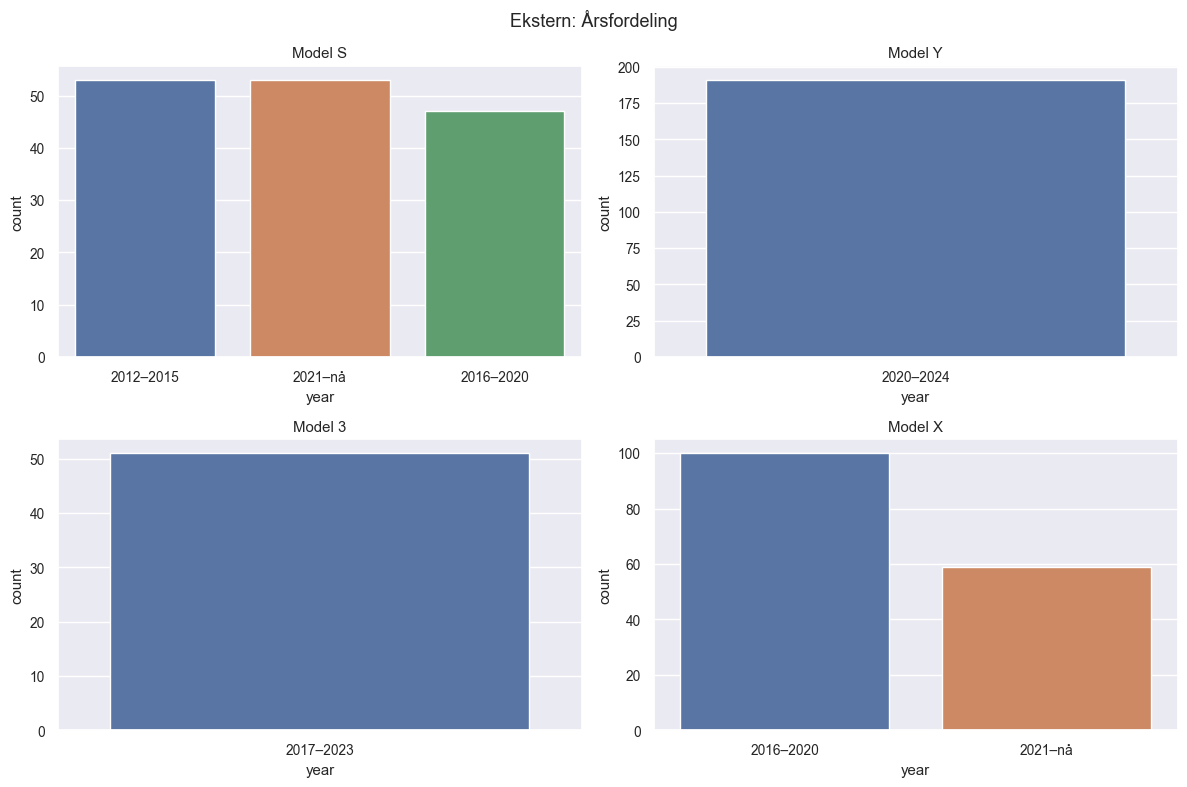

In [15]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Årsfordeling')

    axs = axes.flatten()

    for ax, (model_name, model) in zip(axs, annotation["by_model"].items()):
        sns.countplot(x='year', data=model, ax=ax, hue='year')
        ax.title.set_text(model_name)

    plt.tight_layout()
    plt.show()

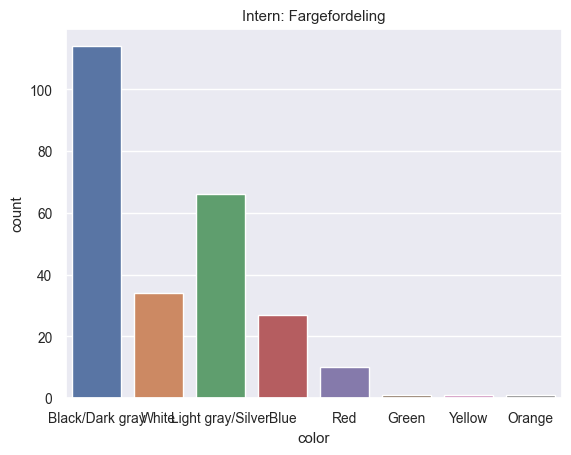

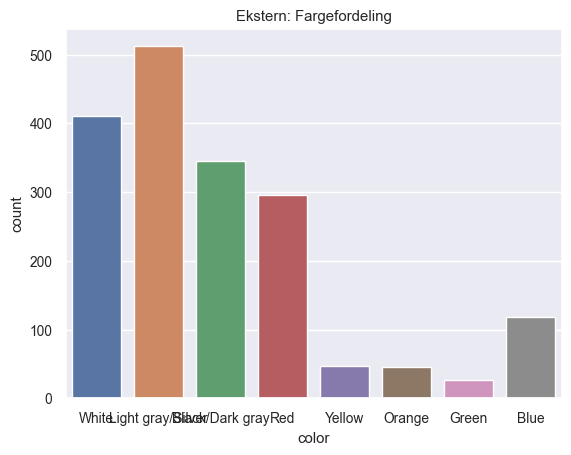

In [16]:
for annotation_name, annotation in annotations.items():
    df = annotation["all"]
    fig = sns.countplot(data=df[df['model'] == other], x='color', hue='color')
    fig.set_title(f'{annotation_name}: Fargefordeling')
    plt.show()


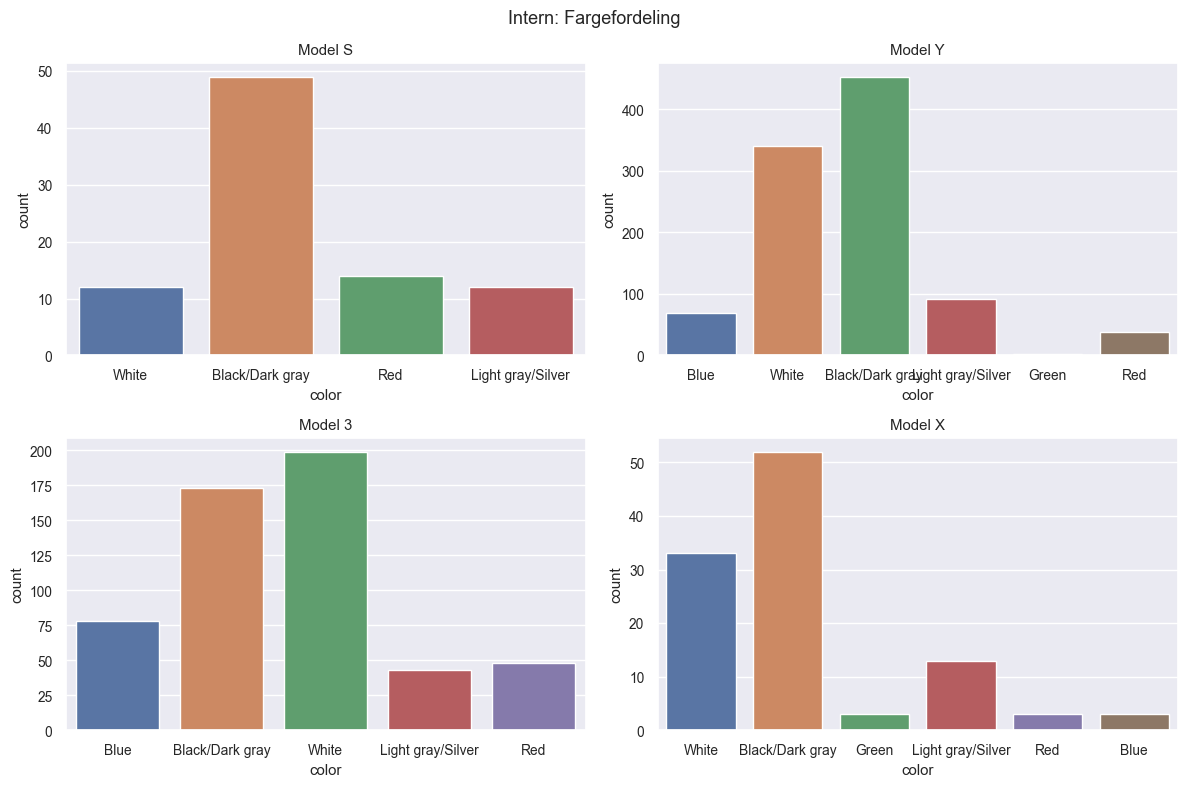

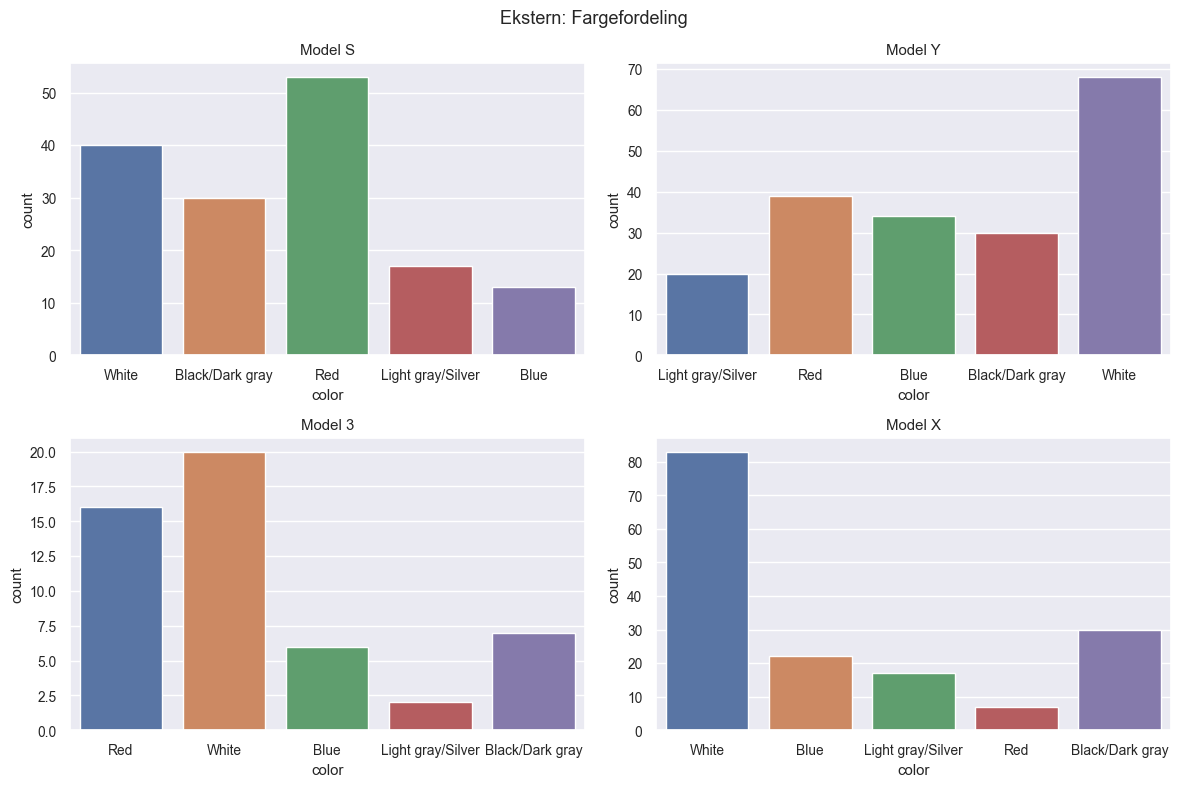

In [17]:
for annotation_name, annotation in annotations.items():
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Fargefordeling')

    axs = axes.flatten()

    for ax, (model_name, model) in zip(axs, annotation["by_model"].items()):
        sns.countplot(x='color', data=model, ax=ax, hue='color')
        ax.title.set_text(model_name)

    plt.tight_layout()
    plt.show()

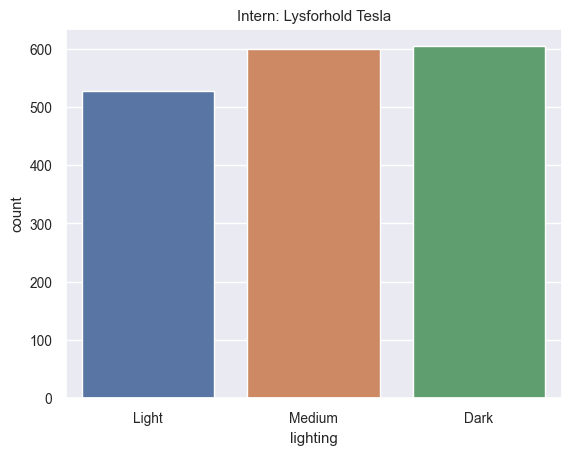

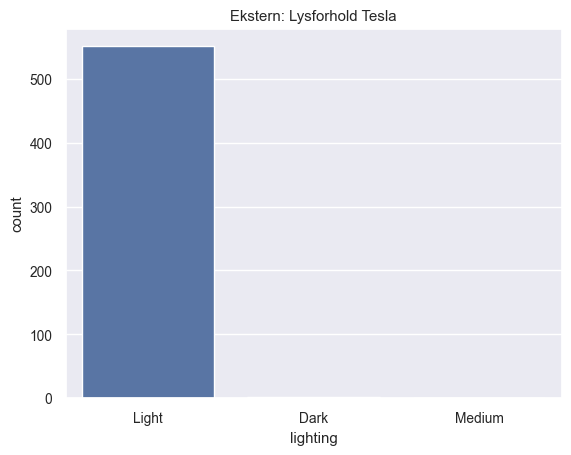

In [18]:
for annotation_name, annotation in annotations.items():
    df = annotation["all"]
    plot = sns.countplot(data=df[df['model'] != other], x='lighting', hue='lighting')
    plot.set_title(f'{annotation_name}: Lysforhold Tesla')
    plt.show()

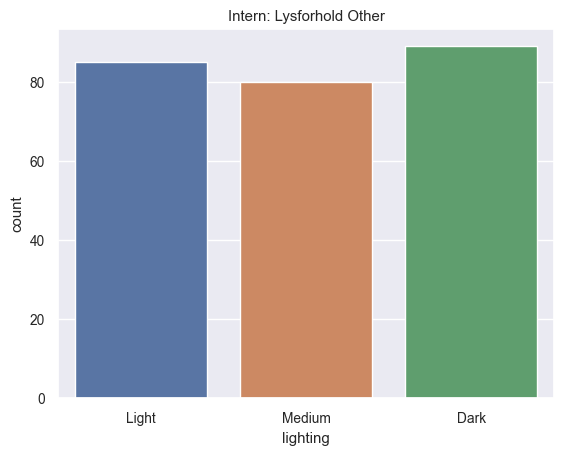

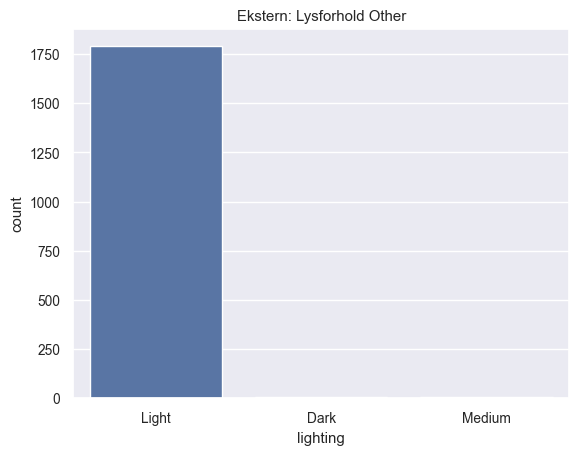

In [19]:
for annotation_name, annotation in annotations.items():
    df = annotation["all"]
    plot = sns.countplot(data=df[df['model'] == other], x='lighting', hue='lighting')
    plot.set_title(f'{annotation_name}: Lysforhold Other')
    plt.show()

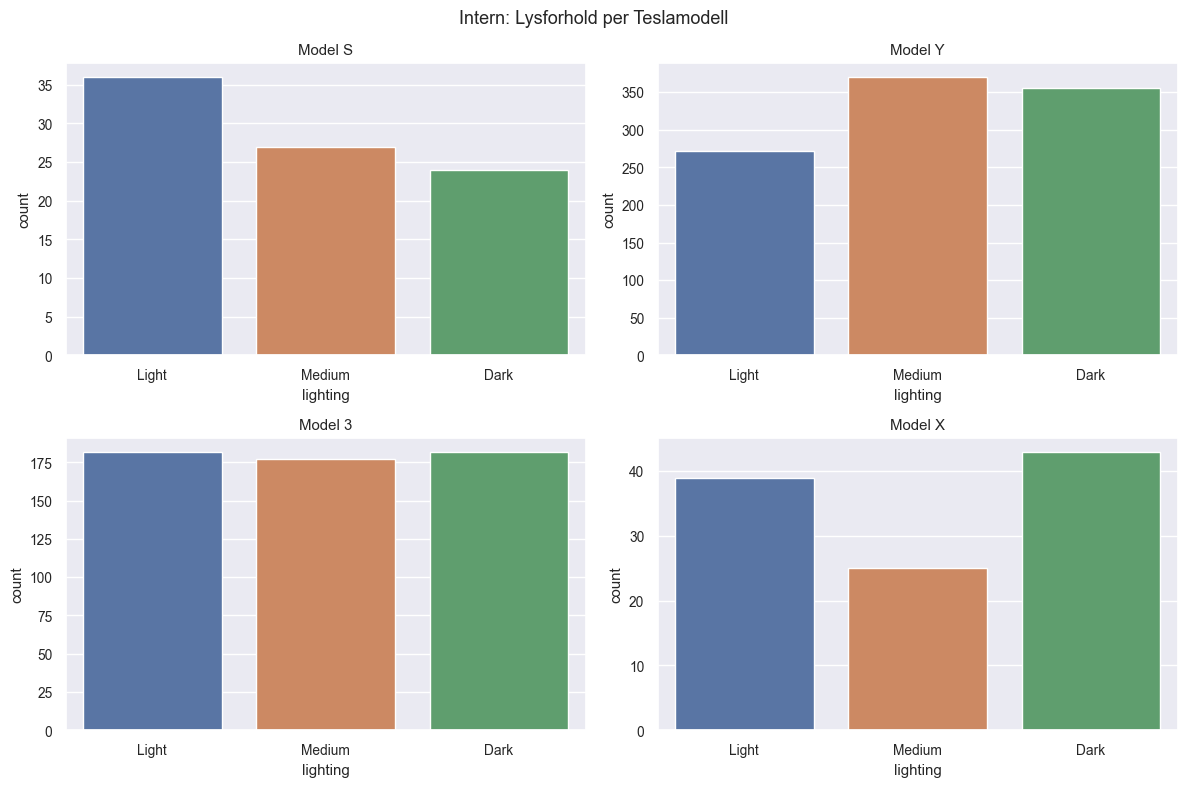

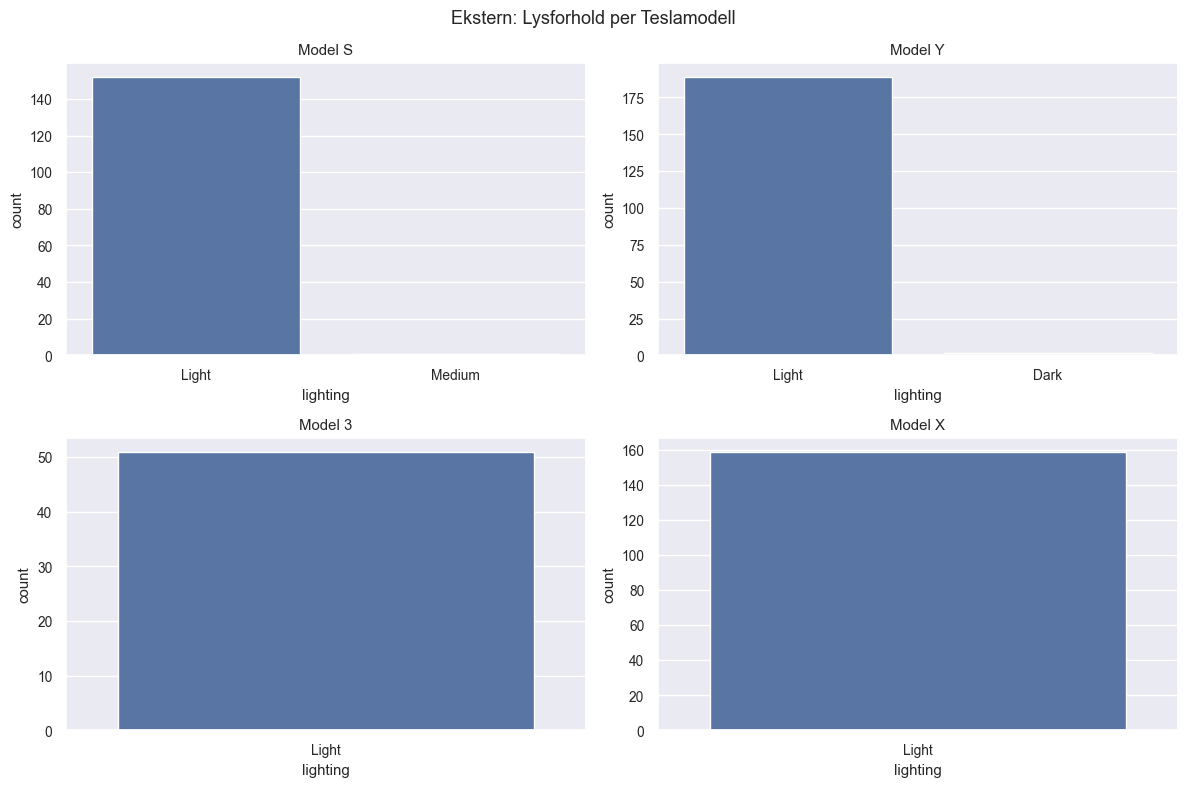

In [20]:
for annotation_name, annotation in annotations.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{annotation_name}: Lysforhold per Teslamodell')

    axs = axes.flatten()

    for ax, (model_name, model) in zip(axs, annotation["by_model"].items()):
        sns.countplot(x='lighting', data=model, ax=ax, hue='lighting')
        ax.title.set_text(model_name)

    plt.tight_layout()
    plt.show()